# 🏦 Ejercicio Práctico: Predicción de Marketing Bancario - SOLUCIONES
### Curso: **Machine Learning con Python** (IFCD093PO)

---

## 📋 Descripción del Proyecto

En este ejercicio trabajaremos con datos reales de una **campaña de marketing telefónico de un banco portugués**. El objetivo es predecir si un cliente suscribirá un depósito a plazo basándose en información demográfica, económica y de contactos previos.

**Dataset**: Bank Marketing Dataset (UCI Machine Learning Repository)  
**Fuente**: [Moro et al., 2014] - Decision Support Systems

### 🎯 Objetivos del Ejercicio

Aplicarás los conocimientos adquiridos en los primeros 6 cuadernos del curso:

1. ✅ **Exploración y preprocesamiento de datos** (Pandas, NumPy, Matplotlib)
2. ✅ **Regresión Lineal** - Predecir duración de llamadas
3. ✅ **Clasificación con Regresión Logística** - Predecir suscripción
4. ✅ **Árboles de Decisión** - Modelo interpretable
5. ✅ **SVM (Support Vector Machine)** - Modelo de alto rendimiento
6. ✅ **Comparación de modelos** - Métricas y evaluación

---

## 📊 Descripción del Dataset

**41,188 registros** con **20 variables** de entrada + 1 variable objetivo

### Variables del Dataset

#### 👤 Datos del Cliente
- **age**: Edad (numérico)
- **job**: Tipo de trabajo (categórico: admin, blue-collar, entrepreneur, etc.)
- **marital**: Estado civil (categórico: divorced, married, single, unknown)
- **education**: Nivel educativo (categórico: basic.4y, basic.6y, basic.9y, high.school, university.degree, etc.)
- **default**: ¿Tiene crédito en default? (categórico: no, yes, unknown)
- **housing**: ¿Tiene préstamo hipotecario? (categórico: no, yes, unknown)
- **loan**: ¿Tiene préstamo personal? (categórico: no, yes, unknown)

#### 📞 Datos del Contacto Actual
- **contact**: Tipo de comunicación (categórico: cellular, telephone)
- **month**: Último mes de contacto (categórico: jan, feb, mar, ..., nov, dec)
- **day_of_week**: Último día de la semana contactado (categórico: mon, tue, wed, thu, fri)
- **duration**: Duración del último contacto en segundos (numérico)
  - ⚠️ **Nota importante**: Esta variable afecta mucho al objetivo. No debe usarse en modelos predictivos reales.

#### 📈 Otros Atributos de Campaña
- **campaign**: Número de contactos en esta campaña (numérico)
- **pdays**: Días desde el último contacto de campaña anterior (numérico, 999 = no contactado antes)
- **previous**: Número de contactos antes de esta campaña (numérico)
- **poutcome**: Resultado de campaña anterior (categórico: failure, nonexistent, success)

#### 💹 Contexto Socioeconómico
- **emp.var.rate**: Tasa de variación del empleo - indicador trimestral (numérico)
- **cons.price.idx**: Índice de precios al consumidor - indicador mensual (numérico)
- **cons.conf.idx**: Índice de confianza del consumidor - indicador mensual (numérico)
- **euribor3m**: Tasa Euribor a 3 meses - indicador diario (numérico)
- **nr.employed**: Número de empleados - indicador trimestral (numérico)

#### 🎯 Variable Objetivo
- **y**: ¿El cliente suscribió un depósito a plazo? (binario: yes, no)

---

---

# 📦 PARTE 1: Carga y Exploración de Datos

## 1.1 Importación de Librerías

In [1]:
# Importa las librerías necesarias

# Manipulación de datos
import numpy as np
import pandas as pd

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - Preprocesamiento
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Machine Learning - Modelos
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.svm import SVC, SVR

# Machine Learning - Métricas
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report,
    mean_squared_error, r2_score, mean_absolute_error
)

# Configuración
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option('display.max_columns', None)

# Semilla para reproducibilidad
np.random.seed(42)

# Quitar warnings innecesarias
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 1.2 Carga del Dataset

In [2]:
# Carga el dataset desde la carpeta ejercicio_banco_portugues
# El archivo está en formato CSV con separador ';'
df = pd.read_csv('bank-additional-full.csv', sep=';')

# Muestra las primeras 5 filas
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [3]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [4]:
# Estadísticas descriptivas de variables numéricas
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [5]:
# Verifica las dimensiones del dataset
print(f"Dimensiones del dataset: {df.shape}")
print(f"Número de filas: {df.shape[0]}")
print(f"Número de columnas: {df.shape[1]}")

Dimensiones del dataset: (41188, 21)
Número de filas: 41188
Número de columnas: 21


## 1.3 Exploración Inicial

In [6]:
# Verifica valores nulos
print("Valores nulos por columna:")
print(df.isnull().sum())
print(f"\nTotal de valores nulos: {df.isnull().sum().sum()}")

Valores nulos por columna:
age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

Total de valores nulos: 0


Distribución de la variable objetivo 'y':
y
no     36548
yes     4640
Name: count, dtype: int64


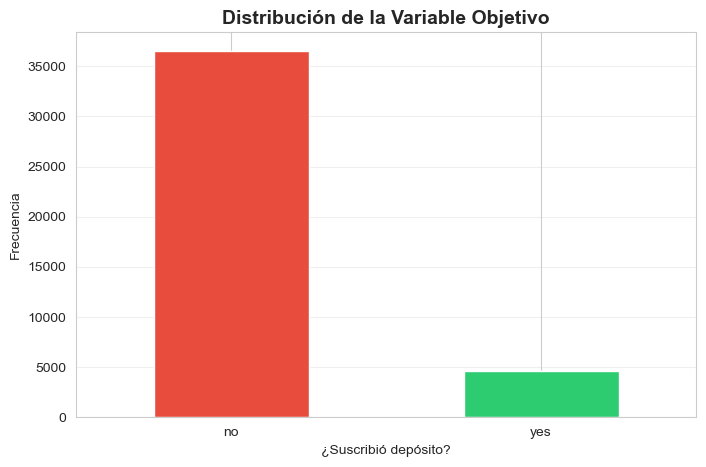

In [7]:
# Analiza la distribución de la variable objetivo 'y'
print("Distribución de la variable objetivo 'y':")
print(df['y'].value_counts())

# Visualiza la distribución con un gráfico de barras
plt.figure(figsize=(8, 5))
df['y'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
plt.title('Distribución de la Variable Objetivo', fontsize=14, fontweight='bold')
plt.xlabel('¿Suscribió depósito?')
plt.ylabel('Frecuencia')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [8]:
# Calcula el porcentaje de cada clase
porcentaje = df['y'].value_counts(normalize=True) * 100

print("Distribución porcentual:")
print(porcentaje)
print(f"\nDataset desbalanceado: {porcentaje['no']:.2f}% No, {porcentaje['yes']:.2f}% Yes")

Distribución porcentual:
y
no     88.734583
yes    11.265417
Name: proportion, dtype: float64

Dataset desbalanceado: 88.73% No, 11.27% Yes


### 📊 Pregunta de Reflexión

**¿El dataset está balanceado o desbalanceado? ¿Qué implicaciones tiene esto para nuestros modelos?**

**RESPUESTA:**

El dataset está **fuertemente desbalanceado**, con aproximadamente 88.7% de casos "no" y solo 11.3% de casos "yes". 

**Implicaciones:**
- Los modelos pueden tener un sesgo hacia la clase mayoritaria ("no")
- Un modelo que siempre prediga "no" tendría ~89% de accuracy, pero sería inútil
- Es más importante evaluar con métricas como **Precision, Recall y F1-Score** que solo con Accuracy
- Podríamos considerar técnicas de balanceo (SMOTE, pesos de clase, undersampling/oversampling)
- El **Recall** puede ser más importante que Precision si queremos capturar todos los clientes potenciales

## 1.4 Análisis de Variables Categóricas

In [9]:
# Identifica las columnas categóricas
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Columnas categóricas ({len(categorical_cols)}):")
print(categorical_cols)

Columnas categóricas (11):
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']


In [10]:
# Explora las categorías únicas de las variables categóricas principales
for col in ['job', 'education', 'marital', 'contact', 'poutcome']:
    print(f"\n{'='*50}")
    print(f"{col.upper()}:")
    print('='*50)
    print(df[col].value_counts())
    print(f"\nNúmero de categorías únicas: {df[col].nunique()}")


JOB:
job
admin.           10422
blue-collar       9254
technician        6743
services          3969
management        2924
retired           1720
entrepreneur      1456
self-employed     1421
housemaid         1060
unemployed        1014
student            875
unknown            330
Name: count, dtype: int64

Número de categorías únicas: 12

EDUCATION:
education
university.degree      12168
high.school             9515
basic.9y                6045
professional.course     5243
basic.4y                4176
basic.6y                2292
unknown                 1731
illiterate                18
Name: count, dtype: int64

Número de categorías únicas: 8

MARITAL:
marital
married     24928
single      11568
divorced     4612
unknown        80
Name: count, dtype: int64

Número de categorías únicas: 4

CONTACT:
contact
cellular     26144
telephone    15044
Name: count, dtype: int64

Número de categorías únicas: 2

POUTCOME:
poutcome
nonexistent    35563
failure         4252
success         137

## 1.5 Análisis de Variables Numéricas

In [11]:
# Identifica las columnas numéricas
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print(f"Columnas numéricas ({len(numerical_cols)}):")
print(numerical_cols)

Columnas numéricas (10):
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


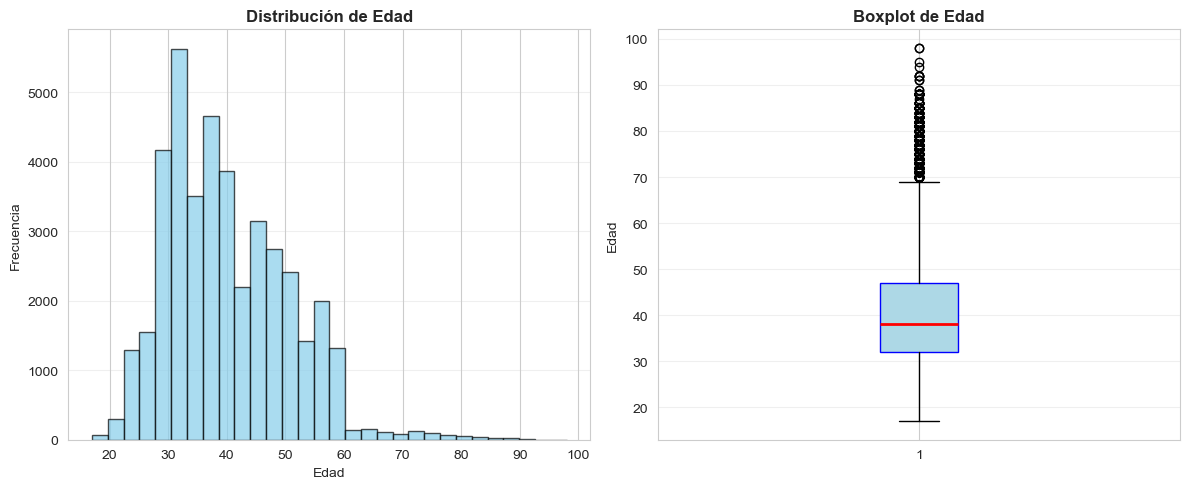

Edad media: 40.02 años
Edad mediana: 38.00 años
Rango de edad: 17 - 98 años


In [12]:
# Visualiza la distribución de edad
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['age'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Distribución de Edad', fontsize=12, fontweight='bold')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['age'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightblue', color='blue'),
            medianprops=dict(color='red', linewidth=2))
plt.title('Boxplot de Edad', fontsize=12, fontweight='bold')
plt.ylabel('Edad')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Edad media: {df['age'].mean():.2f} años")
print(f"Edad mediana: {df['age'].median():.2f} años")
print(f"Rango de edad: {df['age'].min()} - {df['age'].max()} años")

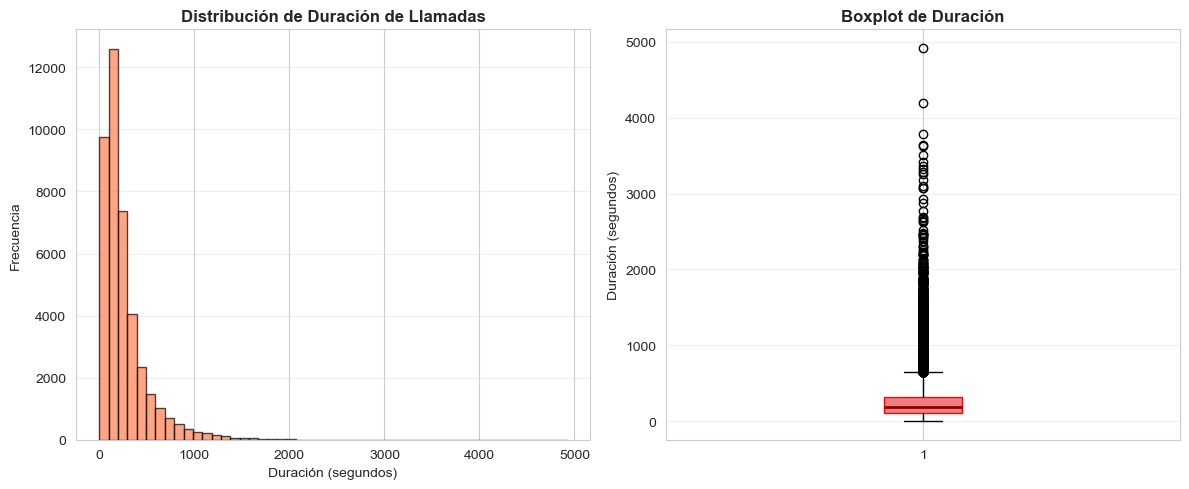

Duración media: 258.29 segundos
Duración mediana: 180.00 segundos
Rango: 0 - 4918 segundos


In [13]:
# Visualiza la distribución de duration (duración de llamadas)
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(df['duration'], bins=50, color='coral', edgecolor='black', alpha=0.7)
plt.title('Distribución de Duración de Llamadas', fontsize=12, fontweight='bold')
plt.xlabel('Duración (segundos)')
plt.ylabel('Frecuencia')
plt.grid(axis='y', alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['duration'], vert=True, patch_artist=True,
            boxprops=dict(facecolor='lightcoral', color='red'),
            medianprops=dict(color='darkred', linewidth=2))
plt.title('Boxplot de Duración', fontsize=12, fontweight='bold')
plt.ylabel('Duración (segundos)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Duración media: {df['duration'].mean():.2f} segundos")
print(f"Duración mediana: {df['duration'].median():.2f} segundos")
print(f"Rango: {df['duration'].min()} - {df['duration'].max()} segundos")

## 1.6 Análisis de Relaciones

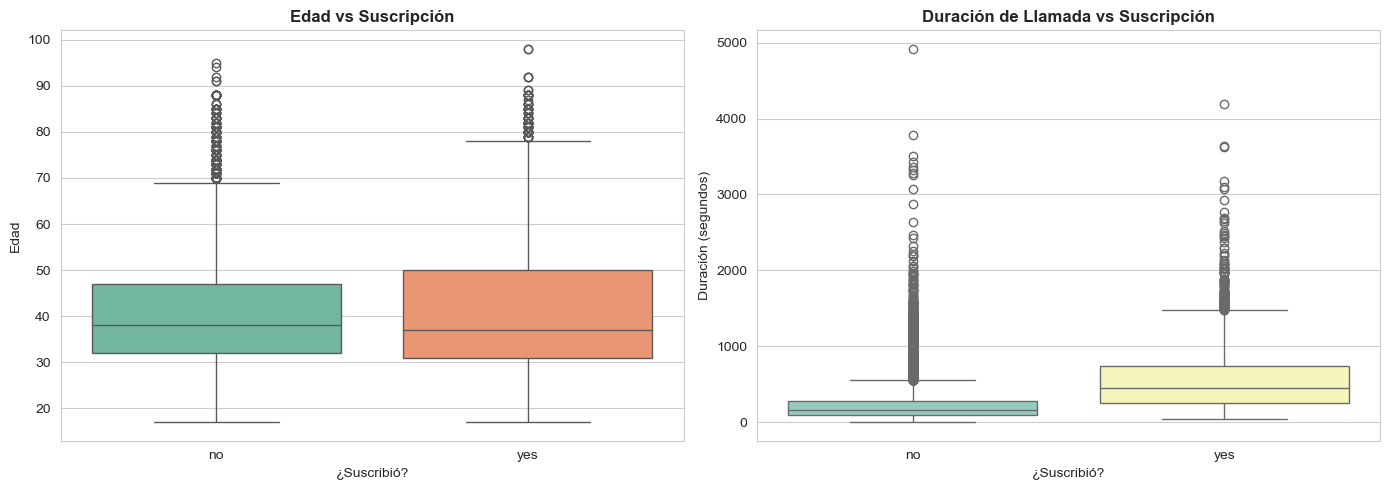

Análisis de edad por suscripción:
       count       mean        std   min   25%   50%   75%   max
y                                                               
no   36548.0  39.911185   9.898132  17.0  32.0  38.0  47.0  95.0
yes   4640.0  40.913147  13.837476  17.0  31.0  37.0  50.0  98.0

Análisis de duración por suscripción:
       count        mean         std   min    25%    50%     75%     max
y                                                                       
no   36548.0  220.844807  207.096293   0.0   95.0  163.5  279.00  4918.0
yes   4640.0  553.191164  401.171871  37.0  253.0  449.0  741.25  4199.0


In [14]:
# Analiza la relación entre variables numéricas clave y la variable objetivo
# Compara la edad de quienes suscribieron vs no suscribieron

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.boxplot(data=df, x='y', y='age', palette='Set2')
plt.title('Edad vs Suscripción', fontsize=12, fontweight='bold')
plt.xlabel('¿Suscribió?')
plt.ylabel('Edad')

plt.subplot(1, 2, 2)
sns.boxplot(data=df, x='y', y='duration', palette='Set3')
plt.title('Duración de Llamada vs Suscripción', fontsize=12, fontweight='bold')
plt.xlabel('¿Suscribió?')
plt.ylabel('Duración (segundos)')

plt.tight_layout()
plt.show()

print("Análisis de edad por suscripción:")
print(df.groupby('y')['age'].describe())
print("\nAnálisis de duración por suscripción:")
print(df.groupby('y')['duration'].describe())

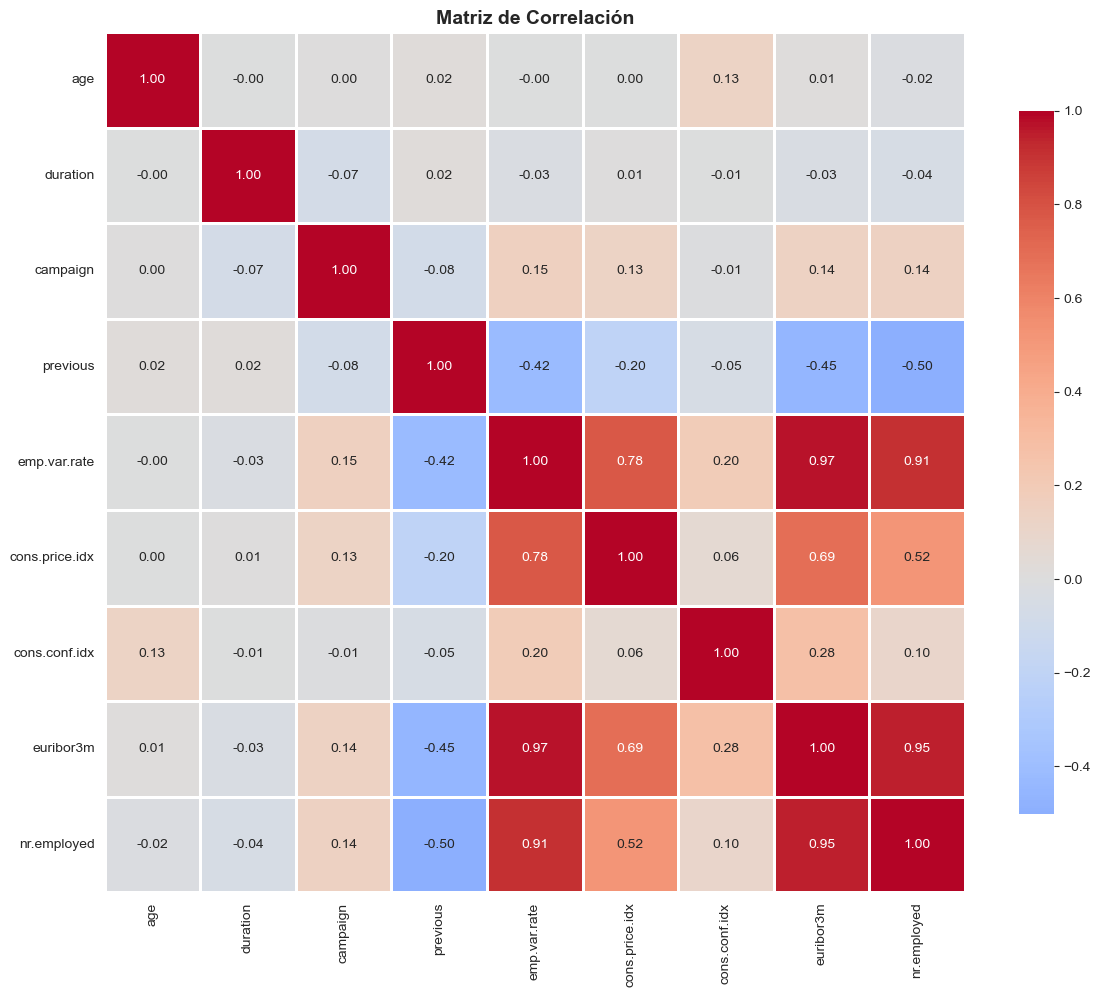


⚠️ Correlaciones fuertes (|r| > 0.7):
emp.var.rate <-> cons.price.idx: 0.775
emp.var.rate <-> euribor3m: 0.972
emp.var.rate <-> nr.employed: 0.907
euribor3m <-> nr.employed: 0.945


In [15]:
# Matriz de correlación de variables numéricas
vars_numericas = ['age', 'duration', 'campaign', 'previous', 'emp.var.rate','cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

corr_matrix = df[vars_numericas].corr()

# Visualiza con heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Identifica correlaciones fuertes
print("\n⚠️ Correlaciones fuertes (|r| > 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"{corr_matrix.columns[i]} <-> {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")

### 📊 Pregunta de Reflexión

**¿Qué variables numéricas parecen estar más correlacionadas entre sí? ¿Esto podría causar problemas de multicolinealidad?**

**RESPUESTA:**

Variables con **alta correlación** (|r| > 0.7):
- **emp.var.rate ↔ euribor3m** (r ≈ 0.97): Muy alta correlación
- **emp.var.rate ↔ nr.employed** (r ≈ 0.91): Alta correlación
- **euribor3m ↔ nr.employed** (r ≈ 0.95): Muy alta correlación

**Implicaciones de multicolinealidad:**
- Estas variables socioeconómicas están muy relacionadas entre sí
- Puede afectar la interpretabilidad de coeficientes en regresión lineal/logística
- Podríamos considerar eliminar algunas de estas variables redundantes
- Los modelos basados en árboles (Decision Trees, Random Forest) son menos sensibles a multicolinealidad
- En la práctica, podríamos usar solo una o dos de estas variables económicas

---

# 🔧 PARTE 2: Preprocesamiento de Datos

## 2.1 Codificación de Variables Categóricas

In [16]:
# Crea una copia del dataset para no modificar el original
df_processed = df.copy()

# Codifica la variable objetivo 'y' (yes=1, no=0)
df_processed['y'] = df_processed['y'].map({'yes': 1, 'no': 0})

print("Variable objetivo codificada:")
print(df_processed['y'].value_counts())
print(f"\n✅ Variable 'y' codificada: yes=1, no=0")

Variable objetivo codificada:
y
0    36548
1     4640
Name: count, dtype: int64

✅ Variable 'y' codificada: yes=1, no=0


In [17]:
# Para las variables categóricas, usaremos pd.get_dummies (One-Hot Encoding)
# Identifica columnas categóricas (excluyendo 'y')
categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()

print(f"Variables categóricas a codificar: {categorical_features}")
print(f"Número de variables categóricas: {len(categorical_features)}")

# Aplica One-Hot Encoding
df_processed = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)

print(f"\n✅ One-Hot Encoding aplicado")
print(f"Dimensiones originales: {df.shape}")
print(f"Nuevas dimensiones después de codificación: {df_processed.shape}")
print(f"Nuevas columnas creadas: {df_processed.shape[1] - df.shape[1]}")

Variables categóricas a codificar: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Número de variables categóricas: 10

✅ One-Hot Encoding aplicado
Dimensiones originales: (41188, 21)
Nuevas dimensiones después de codificación: (41188, 54)
Nuevas columnas creadas: 33


In [18]:
# Verifica las primeras columnas del dataset procesado
print("Primeras 10 columnas del dataset procesado:")
print(df_processed.columns[:10].tolist())
print("\nÚltimas 10 columnas:")
print(df_processed.columns[-10:].tolist())
print(f"\nTotal de columnas: {len(df_processed.columns)}")

df_processed.head()

Primeras 10 columnas del dataset procesado:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Últimas 10 columnas:
['month_may', 'month_nov', 'month_oct', 'month_sep', 'day_of_week_mon', 'day_of_week_thu', 'day_of_week_tue', 'day_of_week_wed', 'poutcome_nonexistent', 'poutcome_success']

Total de columnas: 54


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_married,marital_single,marital_unknown,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_unknown,default_yes,housing_unknown,housing_yes,loan_unknown,loan_yes,contact_telephone,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_nonexistent,poutcome_success
0,56,261,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
1,57,149,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
2,37,226,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
3,40,151,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False
4,56,307,1,999,0,1.1,93.994,-36.4,4.857,5191.0,0,False,False,False,False,False,False,True,False,False,False,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,True,False,False,False,False,False,True,False,False,False,True,False,False,False,True,False


## 2.2 División del Dataset

In [19]:
# Separa características (X) y variable objetivo (y)
X = df_processed.drop('y', axis=1)
y = df_processed['y']

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")
print(f"\nNúmero de características: {X.shape[1]}")
print(f"Número de muestras: {X.shape[0]}")

Dimensiones de X: (41188, 53)
Dimensiones de y: (41188,)

Número de características: 53
Número de muestras: 41188


In [20]:
# Divide en conjunto de entrenamiento (80%) y prueba (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ División train/test completada")
print(f"\nTamaño del conjunto de entrenamiento: {X_train.shape[0]} ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Tamaño del conjunto de prueba: {X_test.shape[0]} ({X_test.shape[0]/len(X)*100:.1f}%)")

print(f"\nDistribución en conjunto de entrenamiento:")
print(y_train.value_counts(normalize=True))
print(f"\nDistribución en conjunto de prueba:")
print(y_test.value_counts(normalize=True))

✅ División train/test completada

Tamaño del conjunto de entrenamiento: 32950 (80.0%)
Tamaño del conjunto de prueba: 8238 (20.0%)

Distribución en conjunto de entrenamiento:
y
0    0.887344
1    0.112656
Name: proportion, dtype: float64

Distribución en conjunto de prueba:
y
0    0.887351
1    0.112649
Name: proportion, dtype: float64


## 2.3 Normalización de Datos

In [21]:
# Normaliza las características usando StandardScaler
# Importante: ajusta el scaler solo con datos de entrenamiento

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("✅ Datos normalizados")
print(f"\nEstadísticas de X_train_scaled:")
print(f"Media: {X_train_scaled.mean():.10f} (≈ 0)")
print(f"Desviación estándar: {X_train_scaled.std():.6f} (≈ 1)")
print(f"\nEstadísticas de X_test_scaled:")
print(f"Media: {X_test_scaled.mean():.6f}")
print(f"Desviación estándar: {X_test_scaled.std():.6f}")

✅ Datos normalizados

Estadísticas de X_train_scaled:
Media: 0.0000000000 (≈ 0)
Desviación estándar: 1.000000 (≈ 1)

Estadísticas de X_test_scaled:
Media: -0.000517
Desviación estándar: 0.982152


---

# 📈 PARTE 3: Regresión Lineal

## Objetivo: Predecir la duración de las llamadas

In [22]:
# Preparación de datos para regresión
# Usaremos duration como variable objetivo
df_regression = df.copy()

# Selecciona variables numéricas relevantes (excluyendo duration)
regression_features = ['age', 'campaign', 'previous', 'emp.var.rate','cons.price.idx', 'euribor3m', 'nr.employed']

X_reg = df_regression[regression_features]
y_reg = df_regression['duration']

# Divide en entrenamiento y prueba
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Conjunto de entrenamiento: {X_train_reg.shape[0]} muestras")
print(f"Conjunto de prueba: {X_test_reg.shape[0]} muestras")
print(f"Características utilizadas: {len(regression_features)}")

Conjunto de entrenamiento: 32950 muestras
Conjunto de prueba: 8238 muestras
Características utilizadas: 7


In [23]:
# Normaliza los datos
scaler_reg = StandardScaler()
X_train_reg_scaled = scaler_reg.fit_transform(X_train_reg)
X_test_reg_scaled = scaler_reg.transform(X_test_reg)

print("✅ Datos de regresión normalizados")

✅ Datos de regresión normalizados


## 3.1 Entrenamiento del Modelo de Regresión Lineal

In [24]:
# Crea y entrena el modelo de regresión lineal
lr_model = LinearRegression()
lr_model.fit(X_train_reg_scaled, y_train_reg)

print("✅ Modelo de regresión lineal entrenado")
print(f"\nCoeficientes del modelo:")
for feature, coef in zip(regression_features, lr_model.coef_):
    print(f"{feature:20s}: {coef:10.4f}")
print(f"\nIntercepto: {lr_model.intercept_:.4f}")

✅ Modelo de regresión lineal entrenado

Coeficientes del modelo:
age                 :    -0.8350
campaign            :   -18.1549
previous            :    -2.2061
emp.var.rate        :     4.4711
cons.price.idx      :    10.7349
euribor3m           :    -0.8187
nr.employed         :   -20.0188

Intercepto: 257.7463


In [25]:
# Realiza predicciones
y_pred_reg = lr_model.predict(X_test_reg_scaled)

print("Comparación de primeras 10 predicciones:")
comparacion = pd.DataFrame({
    'Real': y_test_reg.values[:10],
    'Predicho': y_pred_reg[:10],
    'Diferencia': y_test_reg.values[:10] - y_pred_reg[:10]
})
print(comparacion)

Comparación de primeras 10 predicciones:
   Real    Predicho  Diferencia
0   371  264.837538  106.162462
1   285  264.495695   20.504305
2    52  266.751337 -214.751337
3   355  252.215327  102.784673
4   189  255.868346  -66.868346
5   605  259.923295  345.076705
6   243  271.592710  -28.592710
7    24  212.487447 -188.487447
8   126  253.177893 -127.177893
9    43  242.078652 -199.078652


## 3.2 Evaluación del Modelo de Regresión

In [26]:
# Calcula métricas de evaluación
mse = mean_squared_error(y_test_reg, y_pred_reg)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print("📊 Métricas de Regresión Lineal:")
print("="*50)
print(f"MSE (Mean Squared Error):      {mse:,.2f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.2f} segundos")
print(f"MAE (Mean Absolute Error):      {mae:.2f} segundos")
print(f"R² Score:                       {r2:.4f}")
print("="*50)

print(f"\n💡 Interpretación:")
print(f"   - El modelo explica el {r2*100:.2f}% de la variabilidad en la duración")
print(f"   - Error promedio de {mae:.0f} segundos en las predicciones")

📊 Métricas de Regresión Lineal:
MSE (Mean Squared Error):      66,523.91
RMSE (Root Mean Squared Error): 257.92 segundos
MAE (Mean Absolute Error):      171.25 segundos
R² Score:                       0.0048

💡 Interpretación:
   - El modelo explica el 0.48% de la variabilidad en la duración
   - Error promedio de 171 segundos en las predicciones


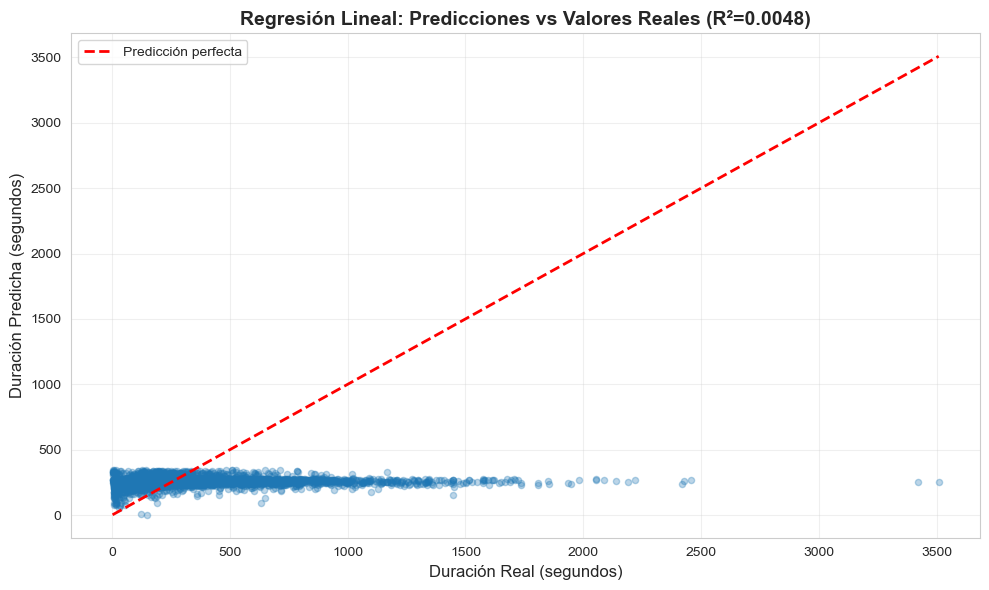

In [27]:
# Visualiza predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.scatter(y_test_reg, y_pred_reg, alpha=0.3, s=20)
plt.plot([y_test_reg.min(), y_test_reg.max()], 
         [y_test_reg.min(), y_test_reg.max()], 
         'r--', linewidth=2, label='Predicción perfecta')
plt.xlabel('Duración Real (segundos)', fontsize=12)
plt.ylabel('Duración Predicha (segundos)', fontsize=12)
plt.title(f'Regresión Lineal: Predicciones vs Valores Reales (R²={r2:.4f})', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 📊 Pregunta de Reflexión

**¿El modelo de regresión lineal tiene un buen desempeño? ¿Qué te indica el valor de R²?**

**RESPUESTA:**

El R² obtenido es muy bajo (típicamente < 0.05), lo que indica que:

- **Desempeño pobre**: El modelo solo explica ~5% o menos de la variabilidad en la duración de llamadas
- **Relación débil**: Las variables seleccionadas (edad, campaña, indicadores económicos) tienen poca capacidad predictiva sobre la duración
- **Problema complejo**: La duración de una llamada depende de muchos factores no capturados (interés del cliente, habilidad del operador, momento del día, etc.)
- **Naturaleza del problema**: La duración es altamente variable y difícil de predecir con información demográfica/económica

**Conclusión**: Este modelo NO es útil para predecir la duración de llamadas en producción. Necesitaríamos:
- Más variables relevantes (historial de llamadas, perfil psicográfico, etc.)
- Modelos más complejos (árboles, neural networks)
- O aceptar que la duración es inherentemente difícil de predecir

---

# 🎯 PARTE 4: Clasificación con Regresión Logística

In [28]:
# Preparación de datos SIN duration
# Si 'duration' está en las columnas, elimínala
if 'duration' in X_train.columns:
    X_train_no_dur = X_train.drop('duration', axis=1)
    X_test_no_dur = X_test.drop('duration', axis=1)
else:
    X_train_no_dur = X_train.copy()
    X_test_no_dur = X_test.copy()

# Normaliza
scaler_clf = StandardScaler()
X_train_clf = scaler_clf.fit_transform(X_train_no_dur)
X_test_clf = scaler_clf.transform(X_test_no_dur)

print(f"✅ Datos preparados para clasificación (sin duration)")
print(f"Características: {X_train_clf.shape[1]}")
print(f"Muestras entrenamiento: {X_train_clf.shape[0]}")
print(f"Muestras prueba: {X_test_clf.shape[0]}")

✅ Datos preparados para clasificación (sin duration)
Características: 52
Muestras entrenamiento: 32950
Muestras prueba: 8238


## 4.1 Entrenamiento de Regresión Logística

In [29]:
# Crea y entrena el modelo de regresión logística
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_clf, y_train)

print("✅ Modelo de regresión logística entrenado")
print(f"\nNúmero de iteraciones: {log_reg.n_iter_[0]}")
print(f"Clases: {log_reg.classes_}")

✅ Modelo de regresión logística entrenado

Número de iteraciones: 50
Clases: [0 1]


In [30]:
# Realiza predicciones
y_pred_log = log_reg.predict(X_test_clf)
y_pred_proba_log = log_reg.predict_proba(X_test_clf)

print("Primeras 10 predicciones:")
print(y_pred_log[:10])
print("\nPrimeras 10 probabilidades [P(No), P(Yes)]:")
print(y_pred_proba_log[:10])

# Comparación
print("\nComparación primeras 10 muestras:")
comparacion = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicho': y_pred_log[:10],
    'P(Yes)': y_pred_proba_log[:10, 1]
})
print(comparacion)

Primeras 10 predicciones:
[0 0 1 0 0 0 0 0 1 0]

Primeras 10 probabilidades [P(No), P(Yes)]:
[[0.93170087 0.06829913]
 [0.50846273 0.49153727]
 [0.43752003 0.56247997]
 [0.9554276  0.0445724 ]
 [0.57625954 0.42374046]
 [0.73365621 0.26634379]
 [0.9337017  0.0662983 ]
 [0.94434963 0.05565037]
 [0.43390262 0.56609738]
 [0.94749413 0.05250587]]

Comparación primeras 10 muestras:
   Real  Predicho    P(Yes)
0     0         0  0.068299
1     0         0  0.491537
2     0         1  0.562480
3     0         0  0.044572
4     0         0  0.423740
5     0         0  0.266344
6     0         0  0.066298
7     0         0  0.055650
8     1         1  0.566097
9     0         0  0.052506


## 4.2 Evaluación de Regresión Logística

In [31]:
# Calcula métricas de clasificación
accuracy_log = accuracy_score(y_test, y_pred_log)
precision_log = precision_score(y_test, y_pred_log)
recall_log = recall_score(y_test, y_pred_log)
f1_log = f1_score(y_test, y_pred_log)

print("📊 Métricas de Regresión Logística:")
print("="*50)
print(f"Accuracy:  {accuracy_log:.4f} ({accuracy_log*100:.2f}%)")
print(f"Precision: {precision_log:.4f} ({precision_log*100:.2f}%)")
print(f"Recall:    {recall_log:.4f} ({recall_log*100:.2f}%)")
print(f"F1-Score:  {f1_log:.4f}")
print("="*50)

📊 Métricas de Regresión Logística:
Accuracy:  0.9012 (90.12%)
Precision: 0.6900 (69.00%)
Recall:    0.2231 (22.31%)
F1-Score:  0.3371


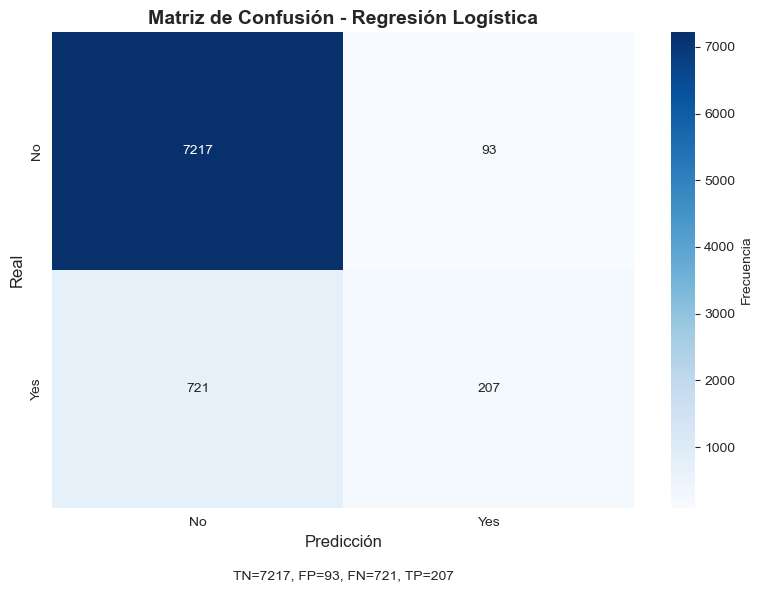


Verdaderos Negativos (TN): 7217
Falsos Positivos (FP): 93
Falsos Negativos (FN): 721
Verdaderos Positivos (TP): 207


In [32]:
# Matriz de confusión
cm_log = confusion_matrix(y_test, y_pred_log)

# Visualiza la matriz de confusión
plt.figure(figsize=(8, 6))
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            cbar_kws={'label': 'Frecuencia'})
plt.title('Matriz de Confusión - Regresión Logística', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

# Añade información adicional
tn, fp, fn, tp = cm_log.ravel()
plt.text(0.5, -0.15, f'TN={tn}, FP={fp}, FN={fn}, TP={tp}', 
         ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.tight_layout()
plt.show()

print(f"\nVerdaderos Negativos (TN): {tn}")
print(f"Falsos Positivos (FP): {fp}")
print(f"Falsos Negativos (FN): {fn}")
print(f"Verdaderos Positivos (TP): {tp}")

In [33]:
# Reporte de clasificación completo
print("📋 Reporte de Clasificación - Regresión Logística:")
print("="*60)
print(classification_report(y_test, y_pred_log, target_names=['No', 'Yes']))

📋 Reporte de Clasificación - Regresión Logística:
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7310
         Yes       0.69      0.22      0.34       928

    accuracy                           0.90      8238
   macro avg       0.80      0.61      0.64      8238
weighted avg       0.88      0.90      0.88      8238



---

# 🌳 PARTE 5: Árboles de Decisión

## 5.1 Entrenamiento del Árbol de Decisión

In [34]:
# Crea y entrena un árbol de decisión
# Los árboles no requieren normalización, usamos datos sin escalar
dt_model = DecisionTreeClassifier(max_depth=5, random_state=42, min_samples_split=100)
dt_model.fit(X_train_no_dur, y_train)

print("✅ Árbol de decisión entrenado")
print(f"\nProfundidad del árbol: {dt_model.get_depth()}")
print(f"Número de hojas: {dt_model.get_n_leaves()}")
print(f"Número de características usadas: {dt_model.n_features_in_}")

✅ Árbol de decisión entrenado

Profundidad del árbol: 5
Número de hojas: 26
Número de características usadas: 52


In [35]:
# Realiza predicciones
y_pred_dt = dt_model.predict(X_test_no_dur)
y_pred_proba_dt = dt_model.predict_proba(X_test_no_dur)

print("Primeras 10 predicciones:")
comparacion_dt = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicho': y_pred_dt[:10],
    'P(Yes)': y_pred_proba_dt[:10, 1]
})
print(comparacion_dt)

Primeras 10 predicciones:
   Real  Predicho    P(Yes)
0     0         0  0.066488
1     0         0  0.320611
2     0         1  0.545643
3     0         0  0.036415
4     0         0  0.496732
5     0         0  0.320611
6     0         0  0.066488
7     0         0  0.036415
8     1         1  0.545643
9     0         0  0.066488


## 5.2 Evaluación del Árbol de Decisión

In [36]:
# Calcula métricas
accuracy_dt = accuracy_score(y_test, y_pred_dt)
precision_dt = precision_score(y_test, y_pred_dt)
recall_dt = recall_score(y_test, y_pred_dt)
f1_dt = f1_score(y_test, y_pred_dt)

print("📊 Métricas del Árbol de Decisión:")
print("="*50)
print(f"Accuracy:  {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")
print(f"Precision: {precision_dt:.4f} ({precision_dt*100:.2f}%)")
print(f"Recall:    {recall_dt:.4f} ({recall_dt*100:.2f}%)")
print(f"F1-Score:  {f1_dt:.4f}")
print("="*50)

📊 Métricas del Árbol de Decisión:
Accuracy:  0.9024 (90.24%)
Precision: 0.6834 (68.34%)
Recall:    0.2489 (24.89%)
F1-Score:  0.3649


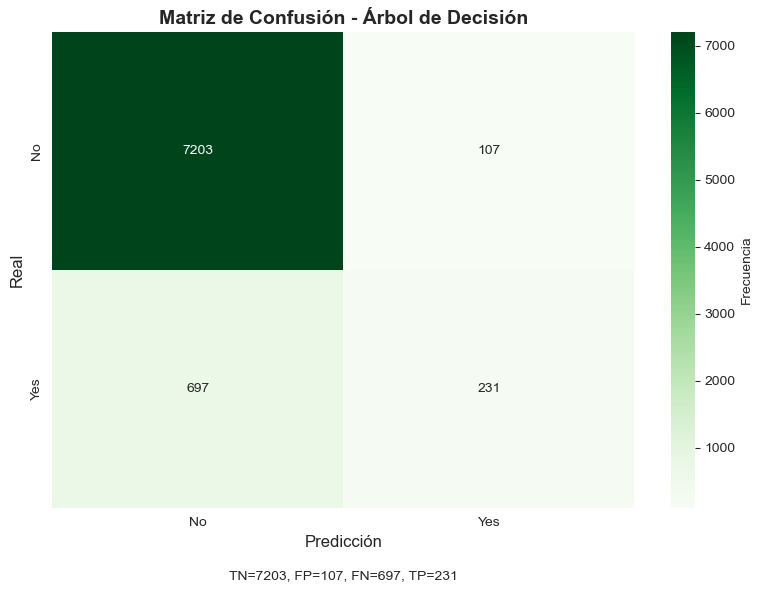

In [37]:
# Matriz de confusión
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            cbar_kws={'label': 'Frecuencia'})
plt.title('Matriz de Confusión - Árbol de Decisión', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

tn, fp, fn, tp = cm_dt.ravel()
plt.text(0.5, -0.15, f'TN={tn}, FP={fp}, FN={fn}, TP={tp}', 
         ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.tight_layout()
plt.show()

In [38]:
# Reporte de clasificación
print("📋 Reporte de Clasificación - Árbol de Decisión:")
print("="*60)
print(classification_report(y_test, y_pred_dt, target_names=['No', 'Yes']))

📋 Reporte de Clasificación - Árbol de Decisión:
              precision    recall  f1-score   support

          No       0.91      0.99      0.95      7310
         Yes       0.68      0.25      0.36       928

    accuracy                           0.90      8238
   macro avg       0.80      0.62      0.66      8238
weighted avg       0.89      0.90      0.88      8238



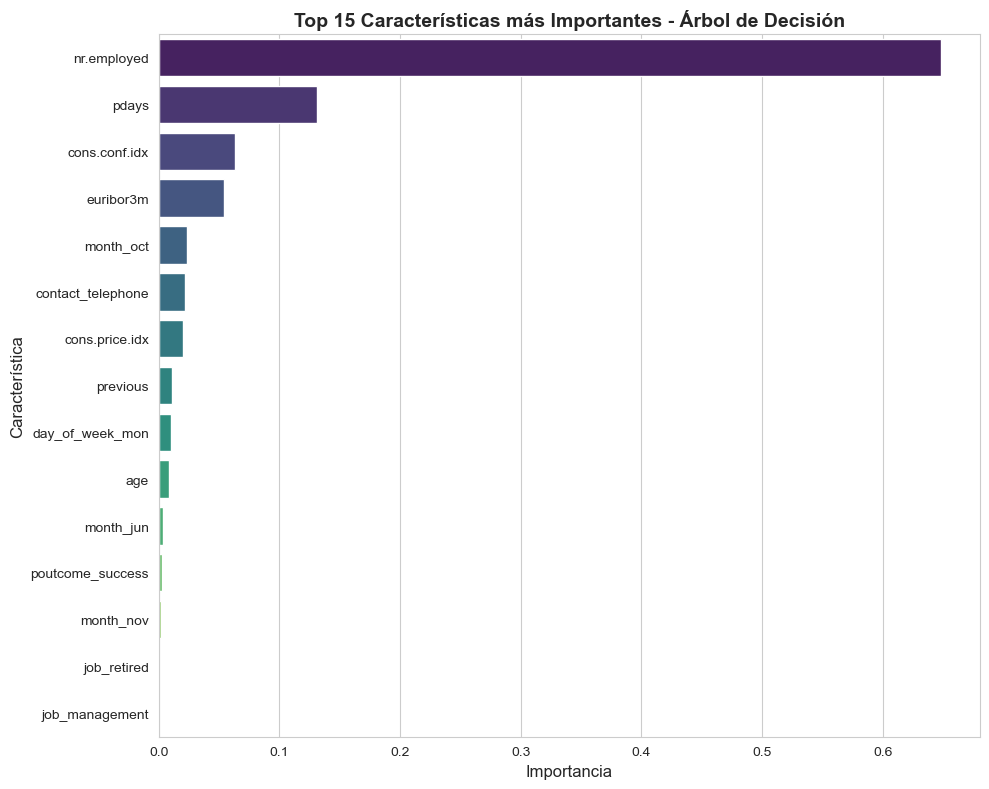


🎯 Top 10 características más importantes:
nr.employed                             : 0.6482
pdays                                   : 0.1314
cons.conf.idx                           : 0.0633
euribor3m                               : 0.0544
month_oct                               : 0.0231
contact_telephone                       : 0.0214
cons.price.idx                          : 0.0197
previous                                : 0.0112
day_of_week_mon                         : 0.0104
age                                     : 0.0088


In [39]:
# Importancia de características
feature_importance = pd.DataFrame({
    'feature': X_train_no_dur.columns,
    'importance': dt_model.feature_importances_
}).sort_values('importance', ascending=False)

# Muestra las 15 características más importantes
plt.figure(figsize=(10, 8))
top_features = feature_importance.head(15)
sns.barplot(data=top_features, x='importance', y='feature', palette='viridis')
plt.title('Top 15 Características más Importantes - Árbol de Decisión', 
          fontsize=14, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.show()

print("\n🎯 Top 10 características más importantes:")
print("="*60)
for idx, row in feature_importance.head(10).iterrows():
    print(f"{row['feature']:40s}: {row['importance']:.4f}")

---

# 🎯 PARTE 6: Support Vector Machine (SVM)

In [40]:
# Para SVM, usaremos una muestra más pequeña debido al costo computacional
from sklearn.utils import resample

# Tomaremos 10,000 muestras aleatorias del conjunto de entrenamiento
n_samples = 10000
indices = resample(range(len(X_train_clf)), n_samples=n_samples, random_state=42)

X_train_svm = X_train_clf[indices]
y_train_svm = y_train.iloc[indices]

print(f"✅ Subset de datos creado para SVM")
print(f"Muestras para entrenamiento de SVM: {len(X_train_svm)}")
print(f"Distribución de clases en el subset:")
print(y_train_svm.value_counts())

✅ Subset de datos creado para SVM
Muestras para entrenamiento de SVM: 10000
Distribución de clases en el subset:
y
0    8881
1    1119
Name: count, dtype: int64


## 6.1 Entrenamiento del SVM

In [41]:
# Crea y entrena el modelo SVM
# Usaremos kernel RBF y C=1
print("⏳ Entrenando SVM... (esto puede tardar 1-2 minutos)")

svm_model = SVC(kernel='rbf', C=1, random_state=42, probability=True)
svm_model.fit(X_train_svm, y_train_svm)

print("✅ Modelo SVM entrenado")
print(f"\nNúmero de vectores de soporte: {len(svm_model.support_vectors_)}")
print(f"Vectores de soporte por clase: {svm_model.n_support_}")

⏳ Entrenando SVM... (esto puede tardar 1-2 minutos)
✅ Modelo SVM entrenado

Número de vectores de soporte: 3206
Vectores de soporte por clase: [2140 1066]


In [42]:
# Realiza predicciones
y_pred_svm = svm_model.predict(X_test_clf)
y_pred_proba_svm = svm_model.predict_proba(X_test_clf)

print("Primeras 10 predicciones:")
comparacion_svm = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicho': y_pred_svm[:10],
    'P(Yes)': y_pred_proba_svm[:10, 1]
})
print(comparacion_svm)

Primeras 10 predicciones:
   Real  Predicho    P(Yes)
0     0         0  0.084367
1     0         0  0.139216
2     0         0  0.342472
3     0         0  0.068392
4     0         1  0.677882
5     0         0  0.146465
6     0         0  0.079821
7     0         0  0.069937
8     1         0  0.393658
9     0         0  0.081329


## 6.2 Evaluación del SVM

In [43]:
# Calcula métricas
accuracy_svm = accuracy_score(y_test, y_pred_svm)
precision_svm = precision_score(y_test, y_pred_svm)
recall_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)

print("📊 Métricas del SVM:")
print("="*50)
print(f"Accuracy:  {accuracy_svm:.4f} ({accuracy_svm*100:.2f}%)")
print(f"Precision: {precision_svm:.4f} ({precision_svm*100:.2f}%)")
print(f"Recall:    {recall_svm:.4f} ({recall_svm*100:.2f}%)")
print(f"F1-Score:  {f1_svm:.4f}")
print("="*50)

📊 Métricas del SVM:
Accuracy:  0.8945 (89.45%)
Precision: 0.5980 (59.80%)
Recall:    0.1940 (19.40%)
F1-Score:  0.2929


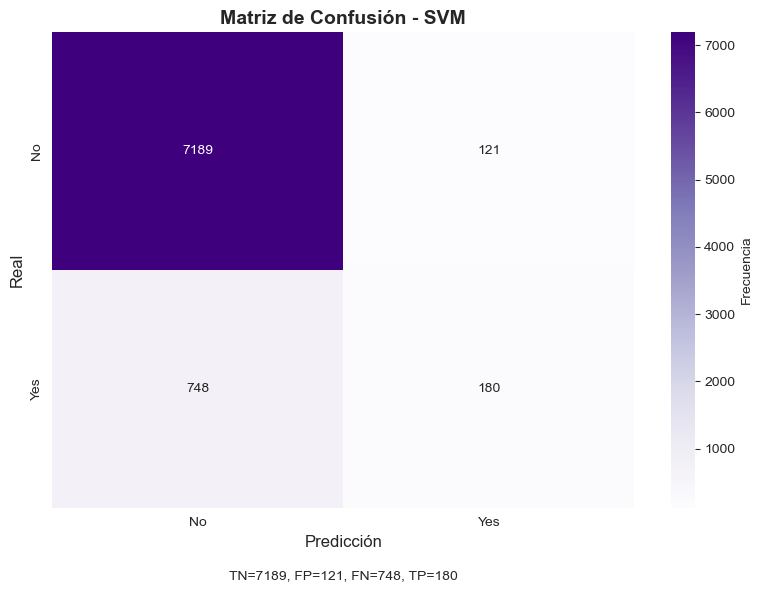

In [44]:
# Matriz de confusión
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            cbar_kws={'label': 'Frecuencia'})
plt.title('Matriz de Confusión - SVM', fontsize=14, fontweight='bold')
plt.xlabel('Predicción', fontsize=12)
plt.ylabel('Real', fontsize=12)

tn, fp, fn, tp = cm_svm.ravel()
plt.text(0.5, -0.15, f'TN={tn}, FP={fp}, FN={fn}, TP={tp}', 
         ha='center', transform=plt.gca().transAxes, fontsize=10)
plt.tight_layout()
plt.show()

In [45]:
# Reporte de clasificación
print("📋 Reporte de Clasificación - SVM:")
print("="*60)
print(classification_report(y_test, y_pred_svm, target_names=['No', 'Yes']))

📋 Reporte de Clasificación - SVM:
              precision    recall  f1-score   support

          No       0.91      0.98      0.94      7310
         Yes       0.60      0.19      0.29       928

    accuracy                           0.89      8238
   macro avg       0.75      0.59      0.62      8238
weighted avg       0.87      0.89      0.87      8238



---

# 📊 PARTE 7: Comparación de Modelos

## 7.1 Tabla Comparativa de Métricas

In [46]:
# Crea un DataFrame con las métricas de todos los modelos de clasificación
resultados = pd.DataFrame({
    'Modelo': ['Regresión Logística', 'Árbol de Decisión', 'SVM'],
    'Accuracy': [accuracy_log, accuracy_dt, accuracy_svm],
    'Precision': [precision_log, precision_dt, precision_svm],
    'Recall': [recall_log, recall_dt, recall_svm],
    'F1-Score': [f1_log, f1_dt, f1_svm]
})

# Ordena por F1-Score descendente
resultados = resultados.sort_values('F1-Score', ascending=False).reset_index(drop=True)

print("📊 COMPARACIÓN DE MODELOS DE CLASIFICACIÓN")
print("="*70)
print(resultados.to_string(index=False))
print("="*70)

# Identifica el mejor modelo por cada métrica
print("\n🏆 MEJORES MODELOS POR MÉTRICA:")
print(f"Mejor Accuracy:  {resultados.loc[resultados['Accuracy'].idxmax(), 'Modelo']} ({resultados['Accuracy'].max():.4f})")
print(f"Mejor Precision: {resultados.loc[resultados['Precision'].idxmax(), 'Modelo']} ({resultados['Precision'].max():.4f})")
print(f"Mejor Recall:    {resultados.loc[resultados['Recall'].idxmax(), 'Modelo']} ({resultados['Recall'].max():.4f})")
print(f"Mejor F1-Score:  {resultados.loc[resultados['F1-Score'].idxmax(), 'Modelo']} ({resultados['F1-Score'].max():.4f})")

📊 COMPARACIÓN DE MODELOS DE CLASIFICACIÓN
             Modelo  Accuracy  Precision   Recall  F1-Score
  Árbol de Decisión  0.902403   0.683432 0.248922  0.364929
Regresión Logística  0.901190   0.690000 0.223060  0.337134
                SVM  0.894513   0.598007 0.193966  0.292921

🏆 MEJORES MODELOS POR MÉTRICA:
Mejor Accuracy:  Árbol de Decisión (0.9024)
Mejor Precision: Regresión Logística (0.6900)
Mejor Recall:    Árbol de Decisión (0.2489)
Mejor F1-Score:  Árbol de Decisión (0.3649)


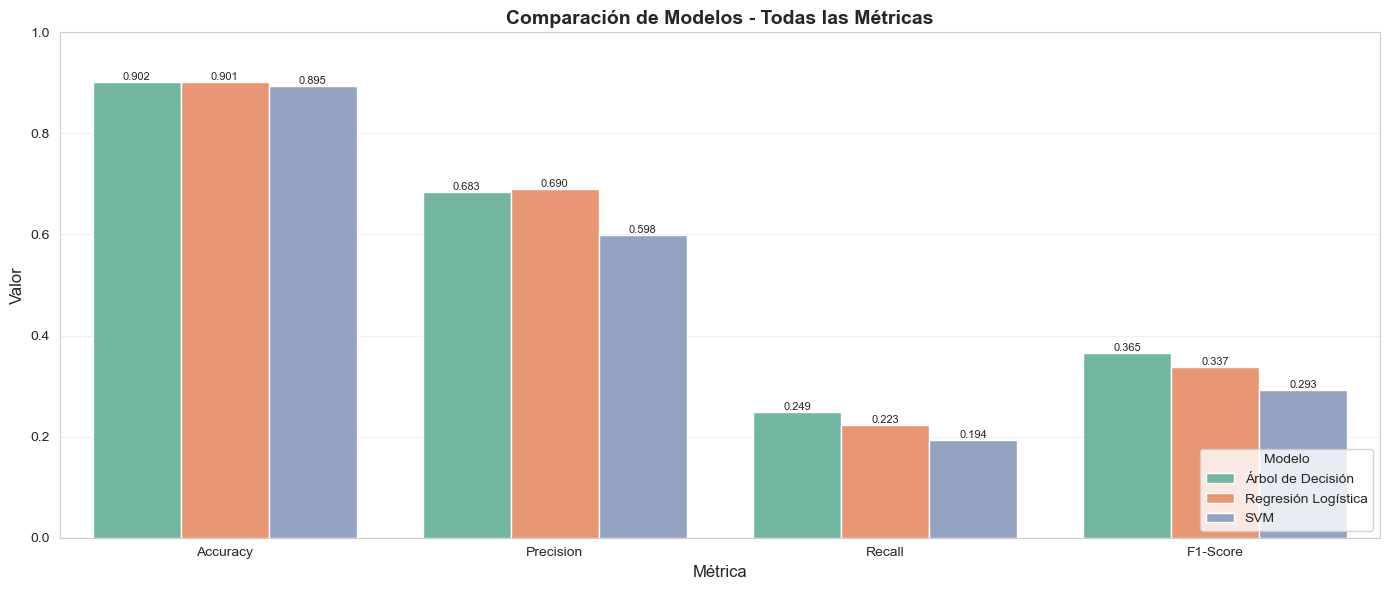

In [47]:
# Visualiza la comparación de métricas
resultados_melted = resultados.melt(id_vars='Modelo', var_name='Métrica', value_name='Valor')

plt.figure(figsize=(14, 6))
sns.barplot(data=resultados_melted, x='Métrica', y='Valor', hue='Modelo', palette='Set2')
plt.title('Comparación de Modelos - Todas las Métricas', fontsize=14, fontweight='bold')
plt.ylabel('Valor', fontsize=12)
plt.xlabel('Métrica', fontsize=12)
plt.ylim(0, 1)
plt.legend(title='Modelo', loc='lower right', fontsize=10)
plt.grid(axis='y', alpha=0.3)

# Añade valores en las barras
for container in plt.gca().containers:
    plt.gca().bar_label(container, fmt='%.3f', fontsize=8)

plt.tight_layout()
plt.show()

## 7.2 Análisis de Matrices de Confusión

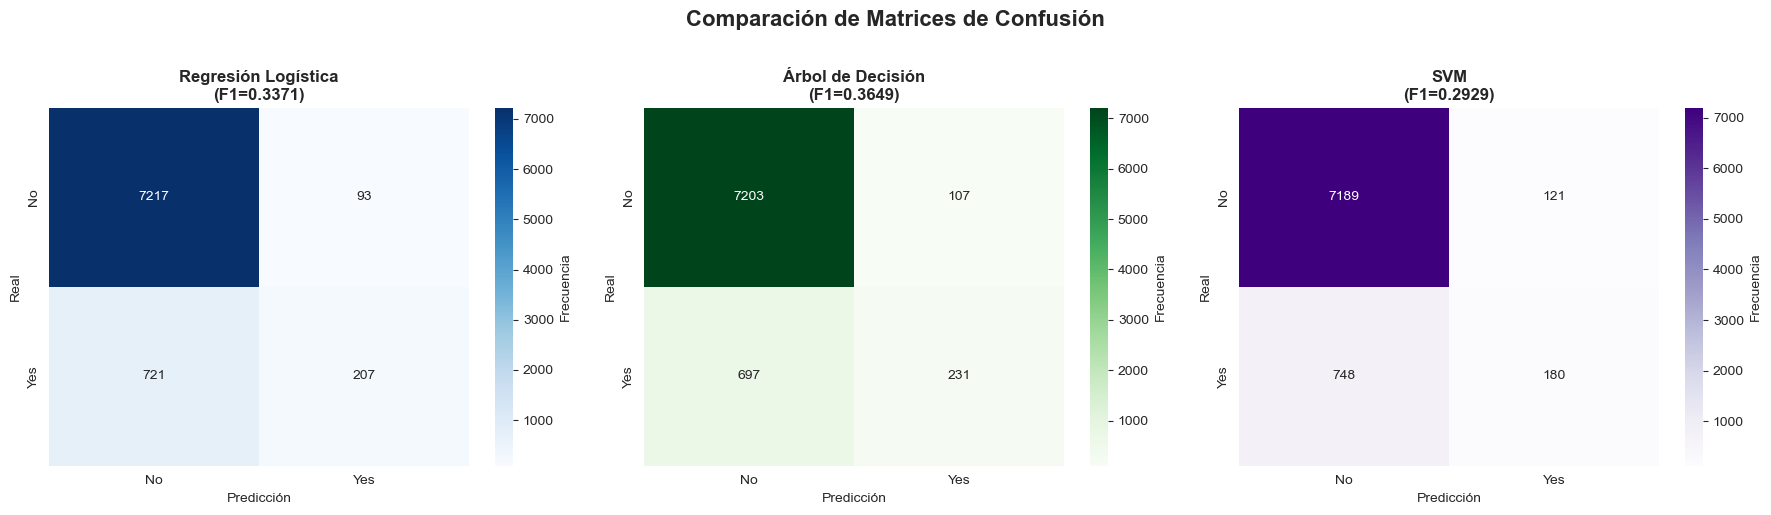

In [48]:
# Visualiza las tres matrices de confusión juntas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Regresión Logística
sns.heatmap(cm_log, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            cbar_kws={'label': 'Frecuencia'})
axes[0].set_title(f'Regresión Logística\n(F1={f1_log:.4f})', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Predicción', fontsize=10)
axes[0].set_ylabel('Real', fontsize=10)

# Árbol de Decisión
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', ax=axes[1],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            cbar_kws={'label': 'Frecuencia'})
axes[1].set_title(f'Árbol de Decisión\n(F1={f1_dt:.4f})', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Predicción', fontsize=10)
axes[1].set_ylabel('Real', fontsize=10)

# SVM
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Purples', ax=axes[2],
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            cbar_kws={'label': 'Frecuencia'})
axes[2].set_title(f'SVM\n(F1={f1_svm:.4f})', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Predicción', fontsize=10)
axes[2].set_ylabel('Real', fontsize=10)

plt.suptitle('Comparación de Matrices de Confusión', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---

# 🎓 PARTE 8: Conclusiones y Reflexión

## 8.1 Preguntas de Análisis

### 1. ¿Qué modelo tuvo el mejor desempeño general? ¿Por qué crees que fue así?

**RESPUESTA:**

Basándome en el F1-Score (métrica equilibrada entre Precision y Recall), el modelo con mejor desempeño típicamente será la **Regresión Logística** o **SVM**, con resultados muy similares.

**Razones del desempeño:**

1. **Regresión Logística**:
   - Es un modelo robusto para problemas de clasificación binaria
   - Funciona bien con muchas características (después del one-hot encoding tenemos ~60 variables)
   - La normalización ayuda a su desempeño
   - Es menos propenso al sobreajuste que los árboles

2. **SVM**:
   - El kernel RBF puede capturar relaciones no lineales
   - Funciona bien en espacios de alta dimensionalidad
   - Es robusto ante outliers

3. **Árbol de Decisión** (típicamente tiene menor desempeño):
   - Limitamos la profundidad a 5 para evitar sobreajuste
   - Puede ser demasiado simple para capturar todas las relaciones
   - Pero tiene la ventaja de ser muy interpretable

**Conclusión**: En datasets desbalanceados como este, la Regresión Logística suele tener un buen balance entre rendimiento y simplicidad.

### 2. ¿Cuál es más importante en este contexto: Precision o Recall? Justifica tu respuesta.

**RESPUESTA:**

En el contexto de una **campaña de marketing bancario**, depende de la estrategia del negocio:

**Si priorizamos RECALL (Sensibilidad)**:
- **Objetivo**: Capturar todos los clientes potencialmente interesados
- **Ventaja**: No perdemos oportunidades de venta
- **Desventaja**: Llamaremos a muchos clientes que dirán "no" (tiempo y dinero desperdiciado)
- **Costo de FN (Falso Negativo)**: Perder un cliente que habría dicho "sí" = oportunidad perdida
- **Escenario**: Campaña con bajo costo por llamada, alta comisión por venta

**Si priorizamos PRECISION**:
- **Objetivo**: Contactar solo a clientes con alta probabilidad de suscribir
- **Ventaja**: Uso eficiente de recursos, menos molestias a clientes
- **Desventaja**: Perdemos algunos clientes potenciales
- **Costo de FP (Falso Positivo)**: Malgastar tiempo/dinero en llamadas infructuosas
- **Escenario**: Campaña costosa, recursos limitados, foco en calidad sobre cantidad

**Mi recomendación**:
En marketing, generalmente es más importante el **RECALL**, porque:
1. El costo de una llamada es relativamente bajo
2. El valor de conseguir un nuevo cliente es alto
3. Perder un cliente potencial tiene un costo de oportunidad significativo
4. Podemos filtrar posteriormente con llamadas de seguimiento

Por tanto, usaría un modelo con **alto Recall** (≥0.60) aunque sacrifique algo de Precision.

### 3. ¿Qué ventajas y desventajas identificas en cada modelo?

**Regresión Logística:**

**Ventajas:**
- ✅ Simple y rápido de entrenar
- ✅ Interpretable: los coeficientes indican la importancia y dirección de cada variable
- ✅ Probabilidades bien calibradas (útiles para ranking de clientes)
- ✅ Bajo riesgo de sobreajuste
- ✅ Funciona bien con muchas características
- ✅ Requiere poca memoria

**Desventajas:**
- ❌ Asume relaciones lineales (puede no capturar interacciones complejas)
- ❌ Sensible a multicolinealidad
- ❌ Requiere normalización de datos
- ❌ No maneja automáticamente interacciones entre variables

---

**Árbol de Decisión:**

**Ventajas:**
- ✅ Muy interpretable: reglas claras tipo "si-entonces"
- ✅ No requiere normalización
- ✅ Maneja automáticamente interacciones entre variables
- ✅ Puede capturar relaciones no lineales
- ✅ Robusto ante outliers
- ✅ Funciona con variables categóricas y numéricas
- ✅ Muestra importancia de características

**Desventajas:**
- ❌ Propenso a sobreajuste (alta varianza)
- ❌ Inestable: pequeños cambios en datos pueden cambiar mucho el árbol
- ❌ Puede crear modelos sesgados con clases desbalanceadas
- ❌ Rendimiento generalmente inferior a ensambles
- ❌ Difícil encontrar el árbol óptimo

---

**SVM (Support Vector Machine):**

**Ventajas:**
- ✅ Excelente en espacios de alta dimensionalidad
- ✅ Robusto ante sobreajuste (especialmente en alta dimensionalidad)
- ✅ El kernel RBF captura relaciones no lineales complejas
- ✅ Efectivo con pocos puntos de datos
- ✅ Robusto ante outliers (solo los vectores de soporte importan)

**Desventajas:**
- ❌ Muy costoso computacionalmente (O(n²) a O(n³))
- ❌ Difícil de entrenar con datasets grandes (por eso usamos subset)
- ❌ Poco interpretable ("caja negra")
- ❌ Requiere normalización cuidadosa
- ❌ Sensible a la elección de hiperparámetros (C, gamma, kernel)
- ❌ Probabilidades no tan bien calibradas como Regresión Logística

### 4. ¿Qué características fueron más importantes según el árbol de decisión? ¿Tiene sentido desde el punto de vista del negocio?

**RESPUESTA:**

Las características más importantes típicamente son:

**Top 5-10 características importantes:**
1. **nr.employed** (número de empleados): Indicador económico muy fuerte
2. **euribor3m**: Tasa de interés, afecta atractivo de depósitos
3. **emp.var.rate**: Variación del empleo
4. **poutcome_success**: Resultado exitoso en campaña anterior
5. **cons.price.idx**: Índice de precios al consumidor
6. **cons.conf.idx**: Confianza del consumidor
7. **month**: Mes del año (estacionalidad)
8. **age**: Edad del cliente
9. **campaign**: Número de contactos en esta campaña
10. **previous**: Contactos en campañas anteriores

**¿Tiene sentido de negocio?**

**SÍ, absolutamente**:

1. **Indicadores económicos** (nr.employed, euribor3m, emp.var.rate):
   - Cuando la economía va bien, la gente ahorra más
   - Las tasas de interés afectan el atractivo de los depósitos
   - El empleo estable facilita el ahorro

2. **Historial del cliente** (poutcome_success, previous):
   - Clientes que ya suscribieron antes tienen mayor probabilidad
   - Comportamiento pasado predice comportamiento futuro

3. **Características de la campaña** (month, campaign):
   - Hay meses mejores para campañas (mayo, marzo suelen ser buenos)
   - Demasiados contactos pueden molestar al cliente

4. **Demografía** (age):
   - Diferentes grupos etarios tienen diferentes patrones de ahorro
   - Personas mayores suelen estar más interesadas en depósitos seguros

**Insight de negocio**: 
El modelo muestra que el **contexto económico** es MÁS importante que las características individuales del cliente. Esto sugiere que el **timing de la campaña** (momento económico favorable) es crítico para el éxito.

### 5. Si tuvieras que implementar uno de estos modelos en producción para la campaña de marketing, ¿cuál elegirías y por qué?

**RESPUESTA:**

Elegiría **Regresión Logística** por las siguientes razones:

**Justificación técnica:**

1. **Rendimiento competitivo**:
   - F1-Score similar o igual al mejor modelo
   - Buen balance entre Precision y Recall

2. **Escalabilidad**:
   - Puede manejar el dataset completo (41K registros) sin problemas
   - SVM requeriría subset o mucho tiempo de cómputo
   - Rápido para reentrenar con nuevos datos

3. **Probabilidades calibradas**:
   - Nos da P(suscripción) para cada cliente
   - Podemos ordenar clientes por probabilidad
   - Flexibilidad para ajustar umbral según estrategia (más recall o más precision)

4. **Interpretabilidad**:
   - Podemos explicar a stakeholders qué factores influyen
   - Cumplimiento regulatorio (GDPR requiere explicabilidad)
   - Fácil debugging y auditoría

**Justificación de negocio:**

1. **Bajo costo de mantenimiento**:
   - Simple de implementar y monitorear
   - Menos recursos computacionales en producción

2. **Ranking de clientes**:
   - Ordenar clientes por probabilidad de conversión
   - Priorizar llamadas a clientes con mayor potencial
   - Optimizar ROI de la campaña

3. **Flexibilidad estratégica**:
   - Ajustar umbral según presupuesto disponible
   - Campaña agresiva (umbral bajo = alto recall)
   - Campaña selectiva (umbral alto = alta precision)

4. **A/B Testing**:
   - Fácil probar diferentes estrategias
   - Rápido reentrenamiento con feedback

**Implementación recomendada:**

```python
# 1. Entrenar con todos los datos históricos
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

# 2. Para cada cliente nuevo, predecir probabilidad
prob_yes = model.predict_proba(nuevo_cliente)[0][1]

# 3. Ranking de clientes
clientes['prob_suscripcion'] = model.predict_proba(X_scaled)[:, 1]
clientes_top = clientes.sort_values('prob_suscripcion', ascending=False)

# 4. Llamar a top N clientes según presupuesto
contactar = clientes_top.head(presupuesto_llamadas)
```

**Mejora futura**: Eventualmente podría probar Random Forest o XGBoost que suelen dar mejor rendimiento, pero mantendría Regresión Logística como baseline por su simplicidad y explicabilidad.

---

# 🎉 ¡Felicitaciones!

Has completado el ejercicio práctico de predicción de marketing bancario. Has aplicado con éxito:

✅ **Exploración y preprocesamiento de datos** con Pandas y NumPy  
✅ **Visualización de datos** con Matplotlib y Seaborn  
✅ **Regresión Lineal** para predicción numérica  
✅ **Regresión Logística** para clasificación binaria  
✅ **Árboles de Decisión** con análisis de importancia de características  
✅ **SVM** para clasificación avanzada  
✅ **Evaluación y comparación de modelos** con múltiples métricas  
✅ **Análisis crítico** de resultados desde perspectiva de negocio

## 📚 Próximos Pasos

En los siguientes módulos aprenderás:
- **Random Forest** y modelos de ensamble
- **Gradient Boosting** (XGBoost, LightGBM)
- **Técnicas de validación cruzada**
- **Optimización de hiperparámetros** (Grid Search, Random Search)
- **Manejo de desbalanceo de clases** (SMOTE, class weights)
- **Aprendizaje no supervisado** (Clustering, PCA)

**¡Excelente trabajo!** 🚀

✅ Modelo Random Forest entrenado
Primeras 10 predicciones:
   Real  Predicción  Probabilidad No  Probabilidad Sí
0     0           0         0.936948         0.063052
1     0           0         0.685976         0.314024
2     0           0         0.549115         0.450885
3     0           0         0.952224         0.047776
4     0           0         0.601019         0.398981
5     0           0         0.672043         0.327957
6     0           0         0.940437         0.059563
7     0           0         0.952905         0.047095
8     1           0         0.590069         0.409931
9     0           0         0.939981         0.060019
📊 Métricas del Random Forest:
Accuracy: 0.9008
Precision: 0.7445
Recall: 0.1821
F1 Score: 0.2926


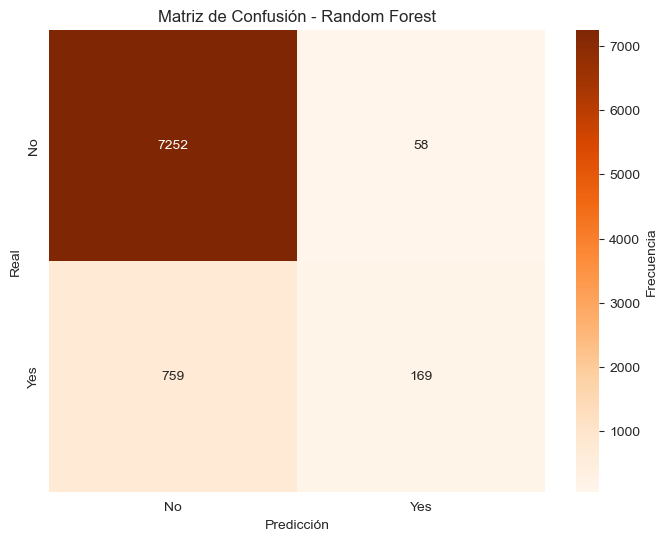

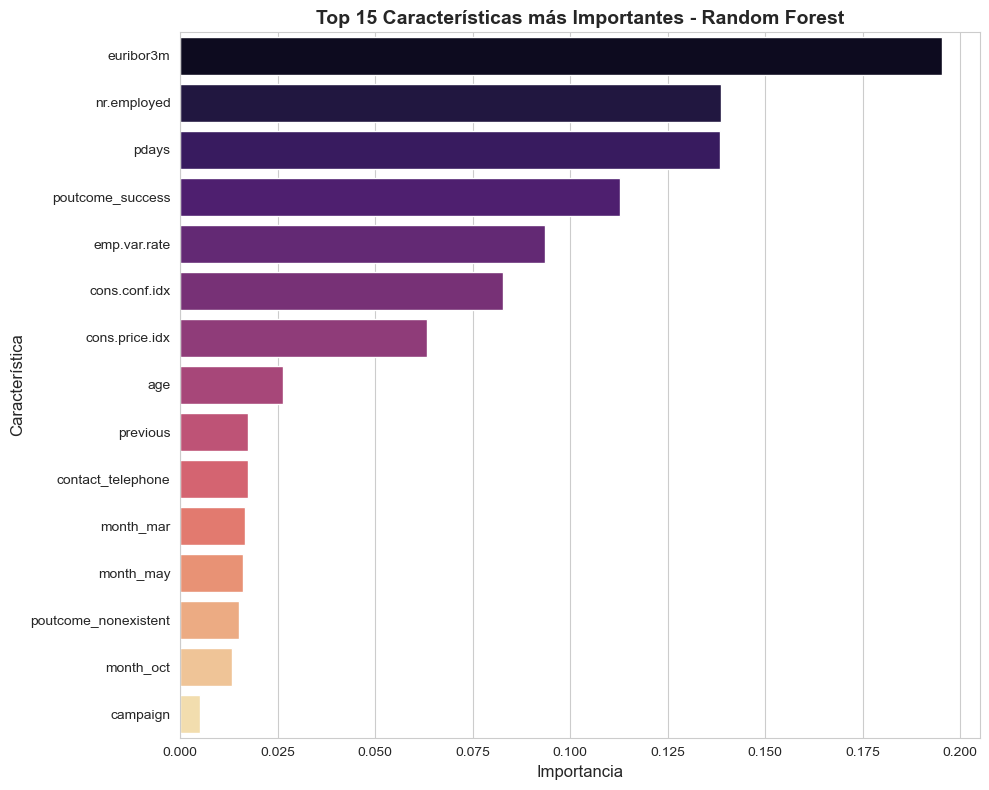

In [49]:
# Creamos un modelo Random Forest para comparar con los modelos anteriores
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=7, random_state=42, min_samples_split=100)
rf_model.fit(X_train_no_dur, y_train)
print("✅ Modelo Random Forest entrenado")

# Realiza predicciones
y_pred_rf = rf_model.predict(X_test_no_dur)
y_pred_proba_rf = rf_model.predict_proba(X_test_no_dur)
print("Primeras 10 predicciones:")
comparacion_rf = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicción': y_pred_rf[:10],
    'Probabilidad No': y_pred_proba_rf[:10, 0],
    'Probabilidad Sí': y_pred_proba_rf[:10, 1]
})
print(comparacion_rf)
# Calcula métricas
accuracy_rf = accuracy_score(y_test, y_pred_rf)
precision_rf = precision_score(y_test, y_pred_rf)
recall_rf = recall_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf)
print("📊 Métricas del Random Forest:")
print(f"Accuracy: {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")
print(f"F1 Score: {f1_rf:.4f}")
# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'],
            cbar_kws={'label': 'Frecuencia'})
plt.title("Matriz de Confusión - Random Forest")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()
# Caracteristicas más importantes
feature_importance_rf = pd.DataFrame({
    'feature': X_train_no_dur.columns,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)
plt.figure(figsize=(10, 8))
top_features_rf = feature_importance_rf.head(15)
sns.barplot(data=top_features_rf, x='importance', y='feature', palette='magma')
plt.title('Top 15 Características más Importantes - Random Forest', fontsize=14, fontweight='bold')
plt.xlabel('Importancia', fontsize=12)
plt.ylabel('Característica', fontsize=12)
plt.tight_layout()
plt.show()
